Para la correcta ejecución de este cuaderno, se procederá a importar los paquetes necesarios para ello.

In [9]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Asimismo, se inicializarán los valores de ancho y alto que serán precisos para la ejecución de algunas tareas.

In [2]:
#Dimensiones de la imagen a crear
ancho = 800
alto = 800

**TAREA 1**: TABLERO DE AJEDREZ

En primer lugar, se dibujará una imagen de fondo negro.

In [3]:
# Crea una imagen con un único plano
chess_img = np.zeros((alto,ancho,1), dtype = np.uint8)

Acto seguido, se procederá al dibujado manual de los baldosas blancas (rectángulos de color blanco) del tablero de ajedrez.

(800, 800, 1)


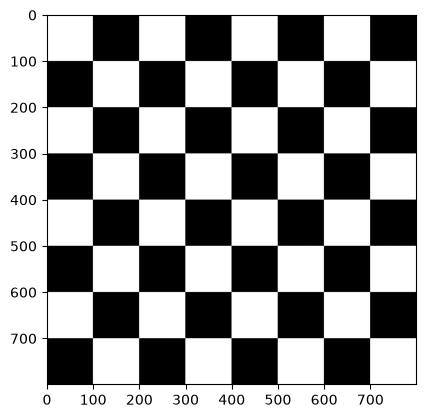

In [4]:
chess_img[0:100, 0:100, 0] = 255
chess_img[200:300, 0:100, 0] = 255
chess_img[400:500, 0:100, 0] = 255
chess_img[600:700, 0:100, 0] = 255

chess_img[100:200, 100:200, 0] = 255
chess_img[300:400, 100:200, 0] = 255
chess_img[500:600, 100:200, 0] = 255
chess_img[700:800, 100:200, 0] = 255

chess_img[0:100, 200:300, 0] = 255
chess_img[200:300, 200:300, 0] = 255
chess_img[400:500, 200:300, 0] = 255
chess_img[600:700, 200:300, 0] = 255

chess_img[100:200, 300:400, 0] = 255
chess_img[300:400, 300:400, 0] = 255
chess_img[500:600, 300:400, 0] = 255
chess_img[700:800, 300:400, 0] = 255

chess_img[0:100, 400:500, 0] = 255
chess_img[200:300, 400:500, 0] = 255
chess_img[400:500, 400:500, 0] = 255
chess_img[600:700, 400:500, 0] = 255

chess_img[100:200, 500:600, 0] = 255
chess_img[300:400, 500:600, 0] = 255
chess_img[500:600, 500:600, 0] = 255
chess_img[700:800, 500:600, 0] = 255

chess_img[0:100, 600:700, 0] = 255
chess_img[200:300, 600:700, 0] = 255
chess_img[400:500, 600:700, 0] = 255
chess_img[600:700, 600:700, 0] = 255

chess_img[100:200, 700:800, 0] = 255
chess_img[300:400, 700:800, 0] = 255
chess_img[500:600, 700:800, 0] = 255
chess_img[700:800, 700:800, 0] = 255

#Dimensiones
print(chess_img.shape)
#Visualiza con matplotlib (sin especificar el mapa de color gris)
plt.imshow(chess_img, cmap='gray') 
plt.show()

Tal y como se observa en el presente código, las filas y columnas se dibujan de 100 en 100 píxeles. Con esta información, se simplificará la creación de la imagen del tablero con la implementación de un bucle a continuación.

(800, 800, 1)


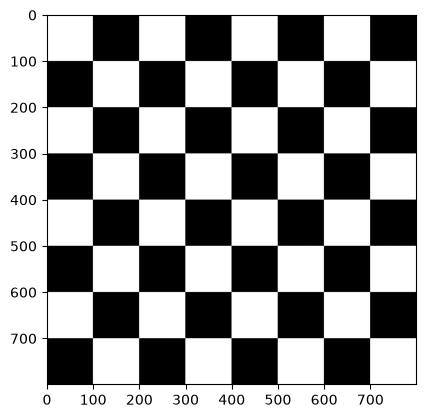

In [ ]:
i = 0
j = 0

while i < alto:
    while j <ancho:
        if (i//100 + j//100) % 2 == 0:
            chess_img[i:i+100, j:j+100, 0] = 255
        j += 100
    j = 0
    i += 100

#Dimensiones
print(chess_img.shape)
#Visualiza con matplotlib (sin especificar el mapa de color gris)
plt.imshow(chess_img, cmap='gray') 
plt.show()


**TAREA 2**: IMAGEN ESTILO MONDRIAN

Para la correcta compleción de esta tarea se deberá generar una imagen inspirada en el estilo del pintor neerlandés Piet Mondrian. Es por ello, que se hará uso de las primitivas que ofrece OpenCV para alcanzar dicho objetivo.


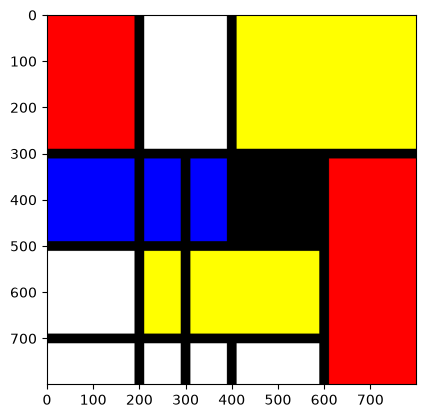

In [6]:
# Crea una imagen con tres planos
mondrian_img = np.zeros((alto,ancho,3), dtype = np.uint8)

# Áreas de color
cv2.rectangle(mondrian_img,(0,0),(200, 300),(255,0,0),-1) # Rojo
cv2.rectangle(mondrian_img,(0,300),(400, 500),(0,0,255),-1) # Azul
cv2.rectangle(mondrian_img,(200,500),(600, 700),(255,255,0),-1) # Amarillo
cv2.rectangle(mondrian_img,(0,500),(200, 800),(255,255,255),-1) # Blanco
cv2.rectangle(mondrian_img,(200,700),(600, 800),(255,255,255),-1) # Blanco
cv2.rectangle(mondrian_img,(600,300),(800, 800),(255,0,0),-1) # Rojo
cv2.rectangle(mondrian_img,(200,0),(400, 300),(255,255,255),-1) # Blanco
cv2.rectangle(mondrian_img,(400,0),(800, 300),(255,255,0),-1) # Amarillo

# Separadores negros

# Horizontales
cv2.line(mondrian_img, (0,300), (800,300), (0,0,0), 20)
cv2.line(mondrian_img, (0,500), (600,500), (0,0,0), 20)
cv2.line(mondrian_img, (0,700), (600,700), (0,0,0), 20)

# Verticales
cv2.line(mondrian_img,(300,300),(300,800),(0,0,0),20)
cv2.line(mondrian_img,(400,700),(400,800),(0,0,0),20)
cv2.line(mondrian_img,(200,0),(200,800),(0,0,0),20)
cv2.line(mondrian_img,(600,300),(600,800),(0,0,0),20)
cv2.line(mondrian_img,(400,0),(400,500),(0,0,0),20)

# Visualiza la imagen resultante
plt.imshow(mondrian_img) 
plt.show()

# Guarda la imagen resultante a disco
# cv2.imwrite('mondrian_img.jpg', mondrian_img)

Con la ejecución de la anterior celda se ha conseguido generar la presente imagen estilo Mondrian, tal como se solicitaba en la tarea.

**TAREA 3**: Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.
 

Con el fin de resolver la tarea propuesta, se partirá de una primera iteración en la que se pintaran los píxeles más claro y oscuro de cada fotograma. Para ello se propone un código simple en el cual cada frame se pasa de manera interna a una escala de grises con el fin de localizar el color más claro y oscuro para cada píxel visible. 

In [7]:
vid = cv2.VideoCapture(0)

while True:      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:
        # Se pasa a escala de grises
        grey_scale = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Sacamos la posición del mínimo y la posición del máximo
        _, _, darkpos, lightpos = cv2.minMaxLoc(grey_scale)
        
        # Dibujamos los círculos sobre el fotograma actual, verde para el más claro y rojo para el más oscuro
        cv2.circle(frame, lightpos, 15, (0, 255, 0), 2)
        cv2.circle(frame, darkpos, 15, (0, 0, 255), 2)

        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()

# Destruye ventanas
cv2.destroyAllWindows()

No obstante, con esta ejecución se puede observar que el funcionamiento se produce a saltos debido al ruido que suelen tener las webcams estándar.

Una solución que se propone es hacer uso de la función GaussianBlur, de la biblioteca _OpenCV_ (Véase el siguiente enlace para más información https://docs.opencv.org/4.13.0/d4/d13/tutorial_py_filtering.html). Con esta función, se conseguirá aplicar un suavizado que prevendrá que el ruido de un píxel aislado afecte de la menor manera posible al resultado. 

In [8]:
vid = cv2.VideoCapture(0)
  
while True:      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:
        # Se pasa a escala de grises
        grey_scale = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) 
        
        # Suavizado para prevenir que el ruido de un píxel aislado no afecte al resultado
        grey_scale = cv2.GaussianBlur(grey_scale, (15, 15), 0)

        # Sacamos la posición del mínimo y la posición del máximo
        _, _, darkpos, lightpos = cv2.minMaxLoc(grey_scale)
        
        # Dibujamos los círculos sobre el fotograma actual, verde para el más claro y rojo para el más oscuro
        cv2.circle(frame, lightpos, 15, (0, 255, 0), 2)
        cv2.circle(frame, darkpos, 15, (0, 0, 255), 2)
        
        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

**TAREA 4**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

Para esta tarea se nos ocurrió hacer algo como la obra de Roy Lichtenstein uno de los artistas más importantes del pop art como en Intenet había muy poca cosa, usamos la asistencia de la IA generativa https://claude.ai/share/0c0735ba-70f1-4550-820b-46b0a62a15e1

In [ ]:
vid = cv2.VideoCapture(0)

# Dimensiones de la cámara, a mitad de resolución
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w)  # En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

# Paleta Lichtenstein (BGR): negro, azul, rojo, amarillo, blanco
paleta = np.array(
    [[0, 0, 0], [190, 80, 0], [30, 30, 220], [0, 215, 255], [255, 255, 255]],
    dtype=np.uint8,
)

# Trama de puntos Ben-Day (se calcula una sola vez)
celda = 6
yy, xx = np.mgrid[0:h, 0:w]
dist = np.hypot(xx % celda - celda / 2, yy % celda - celda / 2)
puntos = dist < celda * 0.35

while True:
    ret, frameIN = vid.read()

    if ret:
        # Tamaño único de salida (w x h)
        frame = cv2.resize(frameIN, (w, h), interpolation=cv2.INTER_NEAREST)

        # Luminosidad suavizada
        gris = cv2.medianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), 5)

        # Cuantizamos la luminosidad en 5 bandas -> colores planos de la paleta
        bandas = np.digitize(gris, [50, 110, 170, 215])
        lich = paleta[bandas]

        # Puntos rojos sobre las zonas amarillas (tonos medios-claros)
        lich[(bandas == 3) & puntos] = paleta[2]

        # Contornos negros gruesos
        bordes = cv2.adaptiveThreshold(gris, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 4)
        lich[bordes == 0] = 0

        cv2.imshow("Lichtenstein", lich)

    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()
